In [20]:
# Basic libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Statistics
from scipy import stats
from scipy.stats import f_oneway

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# Settings
sns.set(style="whitegrid")

In [18]:
import pandas as pd

# Load dataset (make sure file is inside project folder)
df = pd.read_csv("D:\Vedika\drive E\skill1\DV\Diabetes (1) (1).csv")

df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [22]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pregnancies  768 non-null    int64  
 1   glucose      768 non-null    int64  
 2   diastolic    768 non-null    int64  
 3   triceps      768 non-null    int64  
 4   insulin      768 non-null    int64  
 5   bmi          768 non-null    float64
 6   dpf          768 non-null    float64
 7   age          768 non-null    int64  
 8   diabetes     768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Missing Values:
pregnancies    0
glucose        0
diastolic      0
triceps        0
insulin        0
bmi            0
dpf            0
age            0
diabetes       0
dtype: int64


Outlier removal 


In [23]:
# IQR Outlier Removal (numeric columns only)
numeric_cols = df.select_dtypes(include=['number']).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_iqr = df[~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
              (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Outliers removed using IQR")
print(df_iqr.shape)


Outliers removed using IQR
(639, 9)


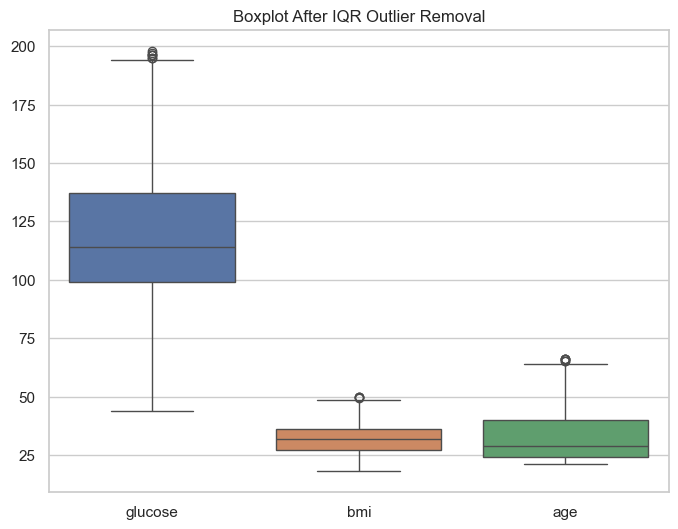

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_iqr[['glucose','bmi','age']])
plt.title("Boxplot After IQR Outlier Removal")
plt.show()

In [27]:
z_scores = stats.zscore(df_iqr[numeric_cols])
abs_z_scores = np.abs(z_scores)

df_z = df_iqr[(abs_z_scores < 3).all(axis=1)]

print("Outliers removed using Z-Score")
print(df_z.shape)

Outliers removed using Z-Score
(629, 9)


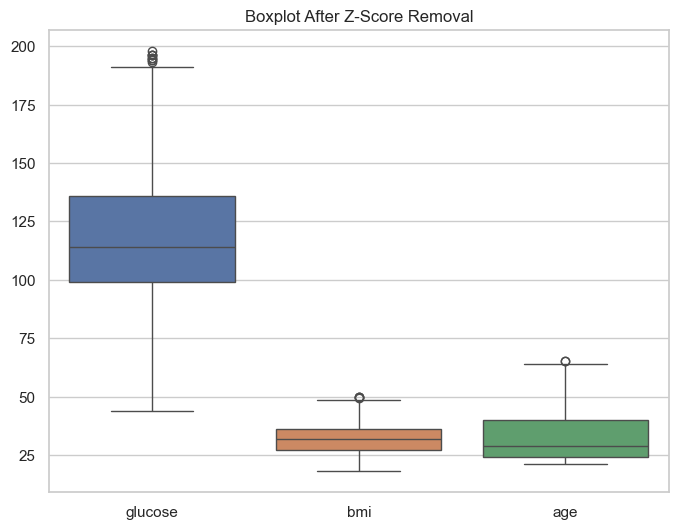

In [28]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_z[['glucose','bmi','age']])
plt.title("Boxplot After Z-Score Removal")
plt.show()

Pearson Correlation Matrix:
             pregnancies   glucose  diastolic   triceps   insulin       bmi  \
pregnancies     1.000000  0.134063   0.207114 -0.091060 -0.111792  0.039730   
glucose         0.134063  1.000000   0.231987  0.011730  0.257828  0.197782   
diastolic       0.207114  0.231987   1.000000  0.047585 -0.035142  0.300162   
triceps        -0.091060  0.011730   0.047585  1.000000  0.487681  0.390624   
insulin        -0.111792  0.257828  -0.035142  0.487681  1.000000  0.184566   
bmi             0.039730  0.197782   0.300162  0.390624  0.184566  1.000000   
dpf             0.002015  0.045560   0.012239  0.164942  0.219478  0.145737   
age             0.576659  0.273286   0.343243 -0.124106 -0.072747  0.072077   
diabetes        0.224249  0.486959   0.179794  0.039094  0.100840  0.273752   

                  dpf       age  diabetes  
pregnancies  0.002015  0.576659  0.224249  
glucose      0.045560  0.273286  0.486959  
diastolic    0.012239  0.343243  0.179794  
trice

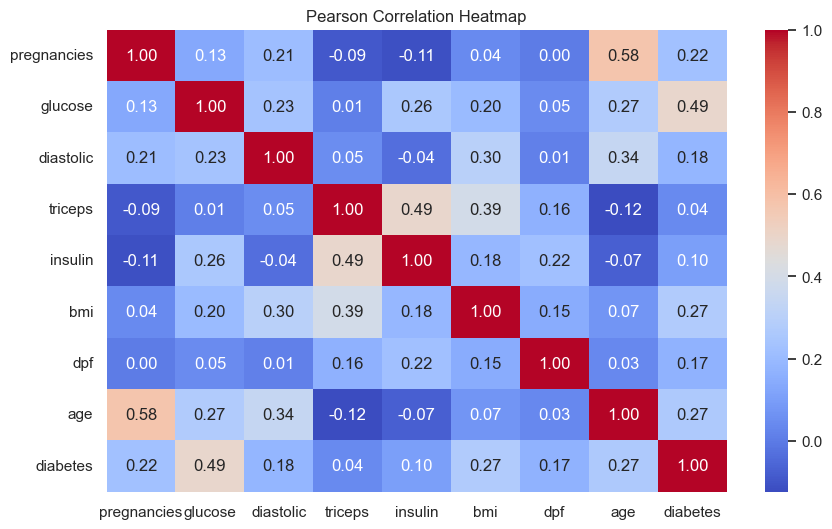

In [29]:
correlation_matrix = df_z.corr(method='pearson')

print("Pearson Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()

In [33]:
# Create age groups
df_z['age'] = pd.qcut(df_z['age'], q=3,labels=['Young','Middle','Old'])

group1 = df_z[df_z['age']=='Young']['glucose']
group2 = df_z[df_z['age']=='Middle']['glucose']
group3 = df_z[df_z['age']=='Old']['glucose']

anova_stat, p_value = f_oneway(group1, group2, group3)

print("ANOVA Results")
print("F-statistic:", anova_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Significant difference between groups")
else:
    print("No significant difference")

ANOVA Results
F-statistic: 24.4111766087482
P-value: 6.186789214482985e-11
Significant difference between groups


C:\Users\vedik\AppData\Local\Temp\ipykernel_3016\3482763971.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_z['age'] = pd.qcut(df_z['age'], q=3,labels=['Young','Middle','Old'])


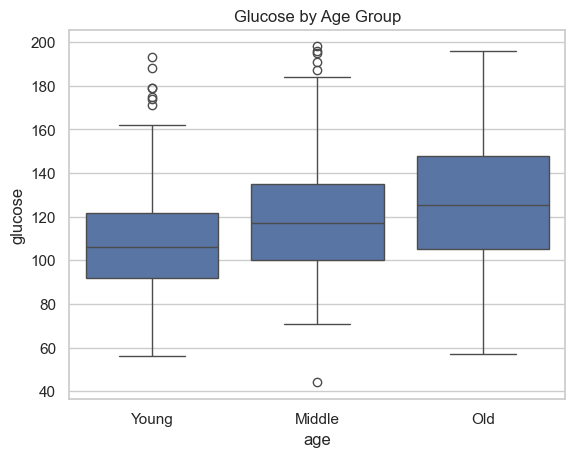

In [34]:
sns.boxplot(x='age', y='glucose', data=df_z)
plt.title("Glucose by Age Group")
plt.show()

Chi square feature selection 

In [ ]:
# Define Features and Target
X = df_z.drop(columns=['diabetes'])
y = df_z['diabetes']

X_numeric = X.select_dtypes(include=['number'])
X_numeric = X_numeric.abs()
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(score_func=chi2, k='all')
X_selected = selector.fit_transform(X_numeric, y)
chi_scores = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Chi-Square Score': selector.scores_
}).sort_values(by='Chi-Square Score', ascending=False)

print("Chi-Square Feature Importance:")
print(chi_scores)

Chi-Square Feature Importance:
       Feature  Chi-Square Score
1      glucose       1048.586289
4      insulin        601.838476
0  pregnancies         88.979308
5          bmi         61.124704
2    diastolic         35.680819
3      triceps         10.868015
6          dpf          2.469433


IG

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

# Define Features and Target
X = df_z.drop(columns=['diabetes'])
y = df_z['diabetes']

X_numeric = X.select_dtypes(include=['number'])
X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42
)
info_gain = mutual_info_classif(X_train, y_train)

info_gain_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Information Gain': info_gain
}).sort_values(by='Information Gain', ascending=False)

print("Feature Importance using Information Gain:")
print(info_gain_df)

Feature Importance using Information Gain:
       Feature  Information Gain
1      glucose          0.103174
0  pregnancies          0.054377
5          bmi          0.048626
2    diastolic          0.044164
3      triceps          0.036888
4      insulin          0.035503
6          dpf          0.007953


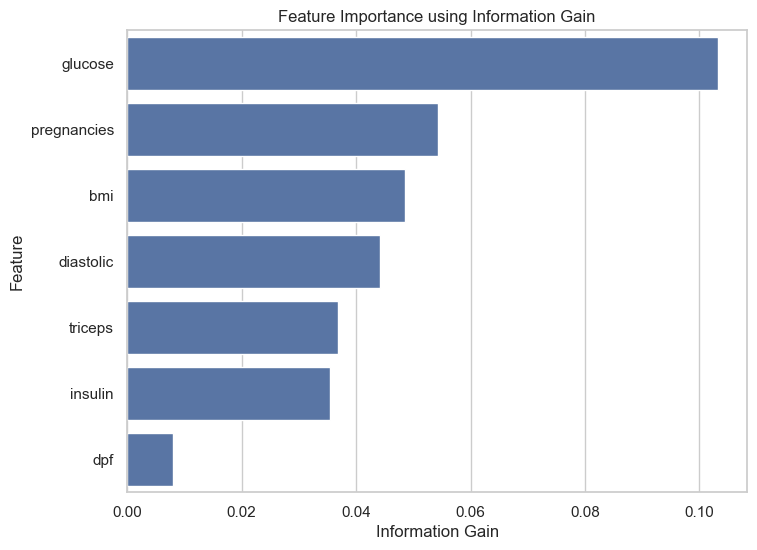

In [38]:
plt.figure(figsize=(8,6))
sns.barplot(x='Information Gain', y='Feature', data=info_gain_df)
plt.title("Feature Importance using Information Gain")
plt.show()

Compare All Feature Selection Methods

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
def pearson_corr(X, y):
    scores = []
    for i in range(X.shape[1]):
        corr = np.corrcoef(X[:, i], y)[0, 1]
        scores.append(abs(corr))
    return np.array(scores), np.zeros(len(scores))


X = df_z.drop(columns=['diabetes'])
y = df_z['diabetes']

X_numeric = X.select_dtypes(include=['number'])
X_numeric = X_numeric.abs()

selectors = [
    (SelectKBest(score_func=pearson_corr, k='all'), 'Pearson Correlation'),
    (SelectKBest(score_func=f_classif, k='all'), 'ANOVA'),
    (SelectKBest(score_func=chi2, k='all'), 'Chi-Square'),
    (SelectKBest(score_func=mutual_info_classif, k='all'), 'Information Gain')
]

results = []

for selector, name in selectors:
    X_selected = selector.fit_transform(X_numeric, y)

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    scores = cross_val_score(model, X_selected, y, cv=5)

    results.append({
        'Method': name,
        'Mean Accuracy': scores.mean(),
        'Std Accuracy': scores.std()
    })
results_df = pd.DataFrame(results).sort_values(
    'Mean Accuracy', ascending=False)

print("\nComparison of Feature Selection Methods:")
print(results_df)


Comparison of Feature Selection Methods:
                Method  Mean Accuracy  Std Accuracy
0  Pearson Correlation       0.763086      0.021873
1                ANOVA       0.763086      0.021873
2           Chi-Square       0.763086      0.021873
3     Information Gain       0.763086      0.021873


Plot Comparison

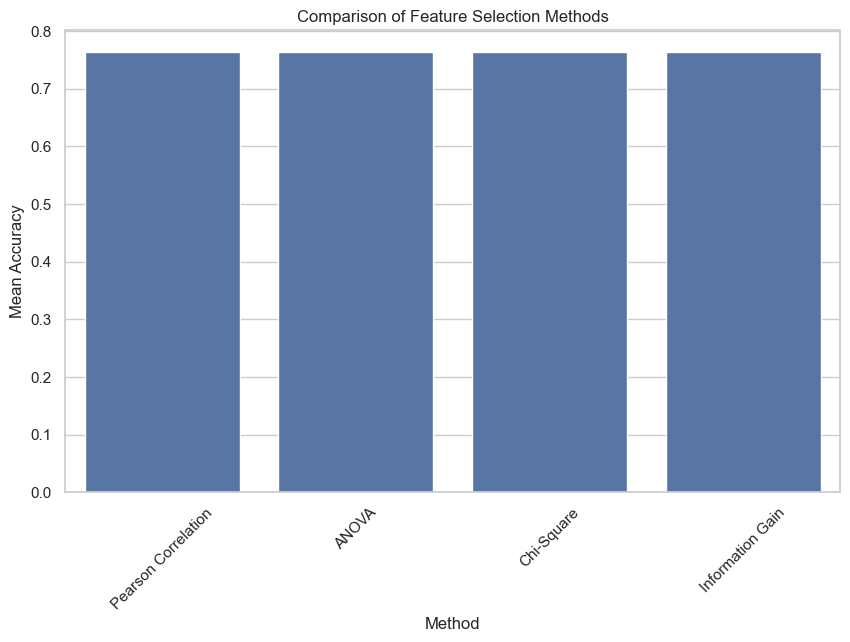

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(x='Method', y='Mean Accuracy', data=results_df)

plt.xticks(rotation=45)
plt.title("Comparison of Feature Selection Methods")
plt.show()

In [41]:
best_method = results_df.iloc[0]

print("BEST METHOD:")
print("Method:", best_method['Method'])
print("Mean Accuracy:", round(best_method['Mean Accuracy'],4))
print("Standard Deviation:", round(best_method['Std Accuracy'],4))

BEST METHOD:
Method: Pearson Correlation
Mean Accuracy: 0.7631
Standard Deviation: 0.0219


In [42]:
best_method = results_df.iloc[0]

print("BEST METHOD:")
print("Method:", best_method['Method'])
print("Mean Accuracy:", round(best_method['Mean Accuracy'],4))
print("Standard Deviation:", round(best_method['Std Accuracy'],4))

BEST METHOD:
Method: Pearson Correlation
Mean Accuracy: 0.7631
Standard Deviation: 0.0219


In [43]:
# Get best selector
best_selector = [s for s, n in selectors if n == best_method['Method']][0]
best_selector.fit(X_numeric, y)

feature_importance = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Importance': best_selector.scores_
}).sort_values(by='Importance', ascending=False)

print("Top Important Features:")
print(feature_importance.head())

Top Important Features:
       Feature  Importance
1      glucose    0.486959
5          bmi    0.273752
0  pregnancies    0.224249
2    diastolic    0.179794
6          dpf    0.166796


In [44]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']

X_numeric = X.select_dtypes(include=['number'])


Correlation with Diabetes:
diabetes       1.000000
glucose        0.466581
bmi            0.292695
age            0.238356
pregnancies    0.221898
dpf            0.173844
insulin        0.130548
triceps        0.074752
diastolic      0.065068
Name: diabetes, dtype: float64


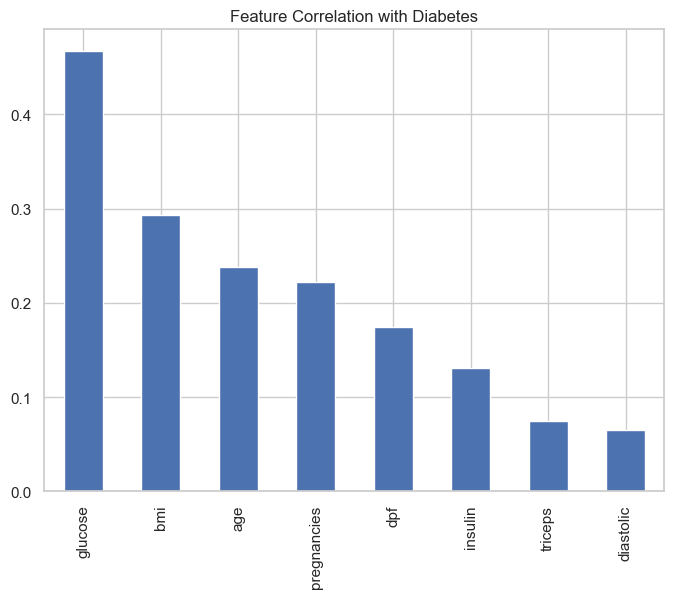

In [45]:
correlation_with_target = df.corr()['diabetes'].sort_values(ascending=False)

print("\nCorrelation with Diabetes:")
print(correlation_with_target)

plt.figure(figsize=(8,6))
correlation_with_target.drop('diabetes').plot(kind='bar')
plt.title("Feature Correlation with Diabetes")
plt.show()

In [46]:
from sklearn.feature_selection import f_classif

f_values, p_values = f_classif(X_numeric, y)

anova_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'F-Score': f_values,
    'P-Value': p_values
}).sort_values(by='F-Score', ascending=False)

print("\nANOVA Feature Importance:")
print(anova_df)


ANOVA Feature Importance:
       Feature     F-Score       P-Value
1      glucose  213.161752  8.935432e-43
5          bmi   71.772072  1.229807e-16
7          age   46.140611  2.209975e-11
0  pregnancies   39.670227  5.065127e-10
6          dpf   23.871300  1.254607e-06
4      insulin   13.281108  2.861865e-04
3      triceps    4.304381  3.834770e-02
2    diastolic    3.256950  7.151390e-02


In [47]:
from sklearn.feature_selection import SelectKBest, chi2

X_chi = X_numeric.copy()
X_chi = X_chi - X_chi.min()  # make all values positive

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_chi, y)

chi_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Chi-Square Score': selector.scores_
}).sort_values(by='Chi-Square Score', ascending=False)

print("\nChi-Square Feature Importance:")
print(chi_df)


Chi-Square Feature Importance:
       Feature  Chi-Square Score
4      insulin       2175.565273
1      glucose       1411.887041
7          age        492.341440
5          bmi        127.669343
0  pregnancies        111.519691
3      triceps         53.108040
2    diastolic         17.605373
6          dpf          6.460604


In [48]:
from sklearn.feature_selection import mutual_info_classif

info_gain = mutual_info_classif(X_numeric, y)

info_df = pd.DataFrame({
    'Feature': X_numeric.columns,
    'Information Gain': info_gain
}).sort_values(by='Information Gain', ascending=False)

print("\nInformation Gain Feature Importance:")
print(info_df)


Information Gain Feature Importance:
       Feature  Information Gain
1      glucose          0.119262
5          bmi          0.087818
7          age          0.062098
4      insulin          0.044126
0  pregnancies          0.019152
6          dpf          0.015507
3      triceps          0.004363
2    diastolic          0.000969


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.7207792207792207

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



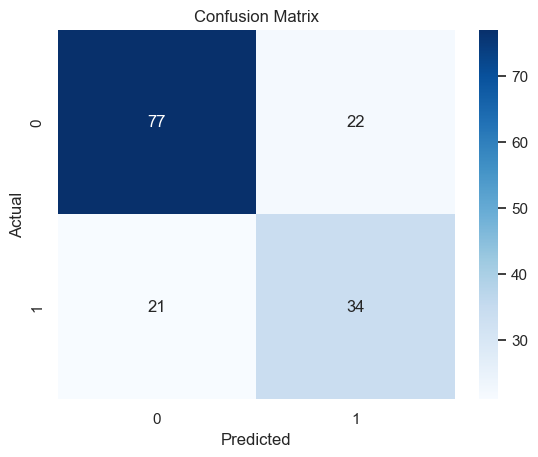

In [50]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Train-Test Split

In [19]:
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv(r"D:\Vedika\drive E\skill1\DV\Diabetes (1) (1).csv")

print("Dataset Loaded Successfully")
print(df.shape)

Dataset Loaded Successfully
(768, 9)


In [ ]:
X = df.drop(columns=['diabetes'])
y = df['diabetes']
X = X.select_dtypes(include=['number'])
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (614, 8)
Test shape: (154, 8)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (614, 8)
Test shape: (154, 8)


In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [25]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7207792207792207

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



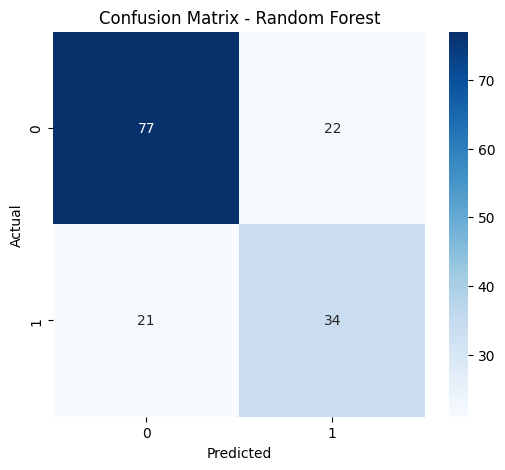

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

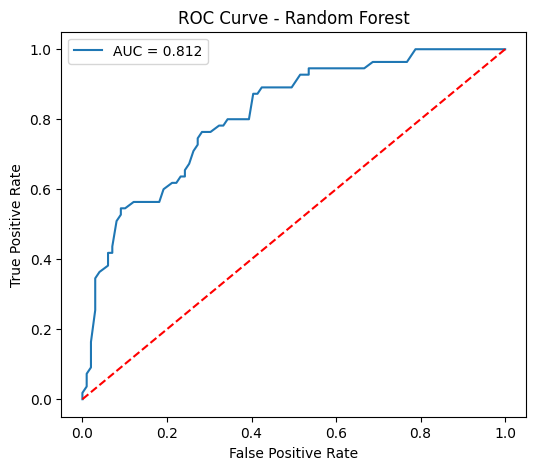

AUC Score: 0.8120293847566575


In [27]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="AUC = " + str(round(roc_auc,4)))
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)

Feature Importance:
       Feature  Importance
1      glucose    0.258864
5          bmi    0.169984
7          age    0.140931
6          dpf    0.123768
2    diastolic    0.088134
0  pregnancies    0.076551
4      insulin    0.076122
3      triceps    0.065646


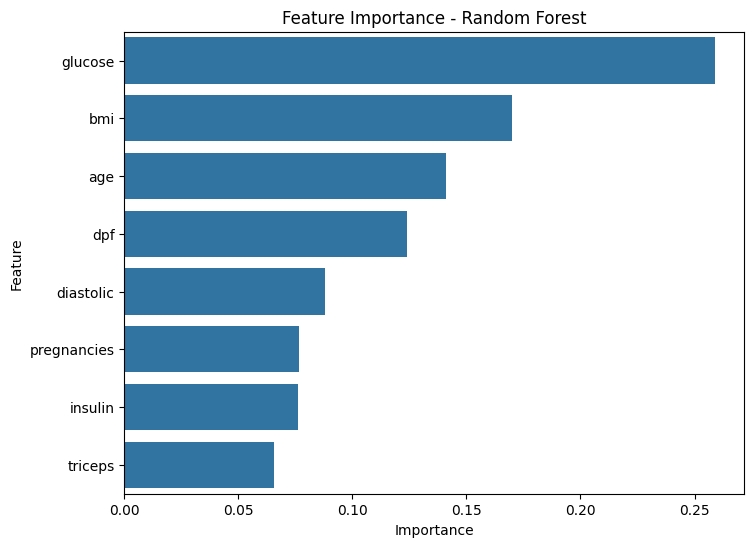

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross Validation Scores: [0.74025974 0.74675325 0.75974026 0.83660131 0.75163399]
Mean CV Accuracy: 0.7669977081741788


In [30]:
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 0.7207792207792207


Logistic Regression

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Logistic Regression Accuracy: 0.7467532467532467

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        99
           1       0.64      0.67      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



AdaBoost (Boosting Model)

In [32]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))
print("\nClassification Report:")
print(classification_report(y_test, ada_pred))

AdaBoost Accuracy: 0.7402597402597403

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        99
           1       0.63      0.67      0.65        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



Model Comparison Table

In [33]:
results = {
    "Random Forest": accuracy_score(y_test, y_pred),
    "Logistic Regression": accuracy_score(y_test, log_pred),
    "AdaBoost": accuracy_score(y_test, ada_pred)
}

import pandas as pd
comparison_df = pd.DataFrame(results.items(), columns=["Model", "Test Accuracy"])

print("\nModel Comparison:")
print(comparison_df)


Model Comparison:
                 Model  Test Accuracy
0        Random Forest       0.720779
1  Logistic Regression       0.746753
2             AdaBoost       0.740260


In [34]:
best_model = comparison_df.sort_values("Test Accuracy", ascending=False).iloc[0]

print("\nBest Model:")
print("Model Name:", best_model["Model"])
print("Accuracy:", best_model["Test Accuracy"])


Best Model:
Model Name: Logistic Regression
Accuracy: 0.7467532467532467


In [35]:
import pickle

with open("final_diabetes_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully!")

Model saved successfully!


In [36]:
with open("final_diabetes_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

In [37]:
import pickle

# assume best model is stored in variable: model
with open("diabetes_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [38]:
# Load model again
with open("diabetes_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

# Test prediction using loaded model
sample_prediction = loaded_model.predict(X_test[:5])
print("Sample Prediction:", sample_prediction)

Model loaded successfully!
Sample Prediction: [0 0 0 0 0]
